In [1]:
# This file is a jupytext-paired Python script export of
# `bayesian_updating_solution.ipynb`. The canonical artifact for learners is
# the notebook (.ipynb); this script is provided for code review and `git diff`
# readability. Run `jupytext --sync` to keep the two in lockstep after edits.

# Updating Demand Beliefs with Bayesian Methods (SOLUTION)

## Scenario

Chapter & Craft, a fictional bookstore and hobby retail chain, pilots a Curated Reader's Box
subscription and must pre-order from its suppliers two weeks in advance. The key unknown is
mean weekly demand per store. Using US hobby/book retail sales data to set a prior, and
simulated pilot scan data for two sequential updates, you'll implement the closed-form
Normal-Normal conjugate update and translate each posterior into a recommended pre-order
quantity.

## What this notebook delivers

1. A prior mean derived from hobby/book retail sales data.
2. Two sequential Normal-Normal updates (prior → Posterior 1 → Posterior 2).
3. A three-distribution plot showing belief sharpening.
4. Pre-order quantities Q under each belief state.

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BENCH_PATH        = "../bayesian-updating-starter/data/hobby_book_industry_benchmarks.csv"
PILOT_BATCH1_PATH = "../bayesian-updating-starter/data/pilot_scan_data_weeks1_4.csv"
PILOT_BATCH2_PATH = "../bayesian-updating-starter/data/pilot_scan_data_weeks5_8.csv"

N_US_HOBBY_BOOK_STORES = 25_000
BOX_SHARE              = 0.008
AVG_BOX_PRICE          = 24.0
PRIOR_SD               = 7.0
Q_BUFFER               = 0.5

## 1. Derive the prior mean from hobby/book sales data

In [3]:
bench = pd.read_csv(BENCH_PATH)
bench.columns = ["date", "sales_m"]
bench["date"] = pd.to_datetime(bench["date"])
bench

,date,sales_m
0,2015-01-01,6656
1,2015-02-01,6696
2,2015-03-01,6787
3,2015-04-01,6796
4,2015-05-01,6851
...,...,...
115,2024-08-01,7801
116,2024-09-01,7973
117,2024-10-01,7875
118,2024-11-01,7845


In [4]:
avg_monthly_usd_m = bench[bench["date"].dt.year >= 2022]["sales_m"].mean()
weekly_per_store  = (avg_monthly_usd_m * 1e6 / N_US_HOBBY_BOOK_STORES) / 4.33
box_per_store      = weekly_per_store * BOX_SHARE
prior_mu = round((box_per_store / AVG_BOX_PRICE) * 0.75, 1)  # 0.75 = early-stage discount

print(f"Avg monthly US hobby/book store sales (2022-24): ${avg_monthly_usd_m:,.0f}M")
print(f"Weekly per-store sales: ${weekly_per_store:,.0f}")
print(f"Derived prior_mu (with early-stage discount): {prior_mu} units/store/week")
print(f"Prior: Demand ~ Normal({prior_mu}, {PRIOR_SD}²)")

Avg monthly US hobby/book store sales (2022-24): $8,114M
Weekly per-store sales: $74,954
Derived prior_mu (with early-stage discount): 18.7 units/store/week
Prior: Demand ~ Normal(18.7, 7.0²)


## 2. Load pilot data: first batch (weeks 1–4)

Load `pilot_scan_data_weeks1_4.csv`. Weeks 5–8 haven't happened yet from the analyst's
point of view — that data lives in a separate file we don't touch until later.

In [5]:
batch1 = pd.read_csv(PILOT_BATCH1_PATH)
batch1

,week,mean_units_sold,n_stores
0,1,20,3
1,2,26,3
2,3,25,3
3,4,27,3


## 3. Compute batch 1's likelihood parameters

The likelihood is summarized by the sample mean and standard error of the weekly
unit counts.

In [6]:
lik1_mu = batch1["mean_units_sold"].mean()
lik1_sd = batch1["mean_units_sold"].std(ddof=1) / np.sqrt(len(batch1))

print(f"Batch 1 likelihood: mu={lik1_mu:.1f}, se={lik1_sd:.2f}")

Batch 1 likelihood: mu=24.5, se=1.55


## 4. Implement `normal_update`

In [7]:
def normal_update(prior_mu: float, prior_sd: float,
                  lik_mu: float, lik_sd: float) -> tuple[float, float]:
    """Conjugate Normal-Normal update. Returns (posterior_mean, posterior_sd)."""
    prior_prec = 1 / prior_sd ** 2
    lik_prec   = 1 / lik_sd ** 2
    post_var   = 1 / (prior_prec + lik_prec)
    post_mu    = post_var * (prior_prec * prior_mu + lik_prec * lik_mu)
    return post_mu, np.sqrt(post_var)

## 5. First update: prior + batch 1

In [8]:
post1_mu, post1_sd = normal_update(prior_mu, PRIOR_SD, lik1_mu, lik1_sd)

print(f"Posterior 1: mu={post1_mu:.1f}, sd={post1_sd:.2f}")
print(f"  Sd reduced: {PRIOR_SD:.1f} → {post1_sd:.2f}")

Posterior 1: mu=24.2, sd=1.52
  Sd reduced: 7.0 → 1.52


## 6. Two weeks later: batch 2 arrives (weeks 5–8)

With Posterior 1 in hand, the pilot keeps running. Now load the next four weeks of scan
data from a separate file — the batch that wasn't available yet when Posterior 1 was
computed.

In [9]:
batch2 = pd.read_csv(PILOT_BATCH2_PATH)
batch2

,week,mean_units_sold,n_stores
0,5,26,8
1,6,29,8
2,7,28,8
3,8,30,8


## 7. Compute batch 2's likelihood parameters

In [10]:
lik2_mu = batch2["mean_units_sold"].mean()
lik2_sd = batch2["mean_units_sold"].std(ddof=1) / np.sqrt(len(batch2))

print(f"Batch 2 likelihood: mu={lik2_mu:.1f}, se={lik2_sd:.2f}")

Batch 2 likelihood: mu=28.2, se=0.85


## 8. Second update: Posterior 1 + batch 2

In [11]:
post2_mu, post2_sd = normal_update(post1_mu, post1_sd, lik2_mu, lik2_sd)

print(f"Posterior 2: mu={post2_mu:.1f}, sd={post2_sd:.2f}")
print(f"  Sd reduced: {post1_sd:.2f} → {post2_sd:.2f}")

Posterior 2: mu=27.3, sd=0.74
  Sd reduced: 1.52 → 0.74


## 9. Plot all three belief distributions

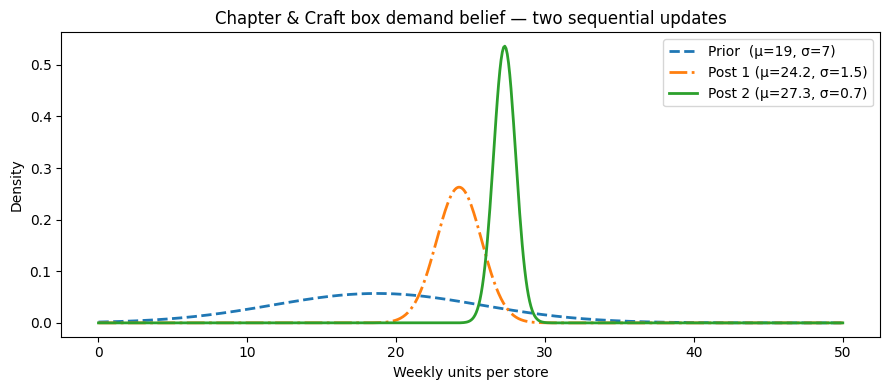

In [12]:
xs = np.linspace(0, 50, 600)

fig, ax = plt.subplots(figsize=(9, 4))
for label, mu, sd, ls in [
    (f"Prior  (μ={prior_mu:.0f}, σ={PRIOR_SD:.0f})",   prior_mu,  PRIOR_SD,  "--"),
    (f"Post 1 (μ={post1_mu:.1f}, σ={post1_sd:.1f})",  post1_mu,  post1_sd,  "-."),
    (f"Post 2 (μ={post2_mu:.1f}, σ={post2_sd:.1f})",  post2_mu,  post2_sd,  "-"),
]:
    ax.plot(xs, stats.norm.pdf(xs, mu, sd), ls, linewidth=2, label=label)

ax.set(title="Chapter & Craft box demand belief — two sequential updates",
       xlabel="Weekly units per store", ylabel="Density")
ax.legend()
plt.tight_layout()
plt.show()

Each update narrows the distribution and shifts the mean toward the pilot's observed
demand (~28 units/week). The prior was wide and anchored conservatively at ~19; by
Posterior 2, almost all probability mass is between 25 and 30 units.

## 10. Recommended pre-order quantity Q

In [13]:
Q_prior = prior_mu  + Q_BUFFER * PRIOR_SD
Q_post1 = post1_mu  + Q_BUFFER * post1_sd
Q_post2 = post2_mu  + Q_BUFFER * post2_sd

summary = pd.DataFrame({
    "belief_state":  ["Prior", "Posterior 1", "Posterior 2"],
    "mean":          [round(prior_mu, 1), round(post1_mu, 1), round(post2_mu, 1)],
    "sd":            [round(PRIOR_SD, 1), round(post1_sd, 1), round(post2_sd, 1)],
    "Q_recommended": [round(Q_prior),     round(Q_post1),     round(Q_post2)],
})
summary

,belief_state,mean,sd,Q_recommended
0,Prior,18.7,7.0,22
1,Posterior 1,24.2,1.5,25
2,Posterior 2,27.3,0.7,28


Q rises from ~22 → 25 → 28 units as evidence pushes the mean estimate up. The buffer
itself also shrinks (0.5 × 7.0 = 3.5 → 0.5 × 1.5 = 0.8) because the posterior is
tighter — Chapter & Craft is more confident and needs less of a safety cushion.